In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("blourdhuraju/intel-image-classification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 243M/243M [00:02<00:00, 86.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/blourdhuraju/intel-image-classification-dataset/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/blourdhuraju/intel-image-classification-dataset/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/blourdhuraju/intel-image-classification-dataset/versions/1):
['Intel-Image-Classification']


In [ ]:
print(f"Contents of the 'train' directory: {os.listdir(os.path.join(path, 'Intel-Image-Classification', 'train'))}")
print(f"Contents of the 'test' directory: {os.listdir(os.path.join(path, 'Intel-Image-Classification', 'test'))}")

Contents of the 'train' directory: ['street', 'sea', 'forest', 'glacier', 'mountain', 'buildings']
Contents of the 'test' directory: ['street', 'sea', 'forest', 'glacier', 'mountain', 'buildings']



--- Sample Images from Training Dataset (/root/.cache/kagglehub/datasets/blourdhuraju/intel-image-classification-dataset/versions/1/Intel-Image-Classification/train) ---
Found 12632 images in /root/.cache/kagglehub/datasets/blourdhuraju/intel-image-classification-dataset/versions/1/Intel-Image-Classification/train. Displaying 6 samples:


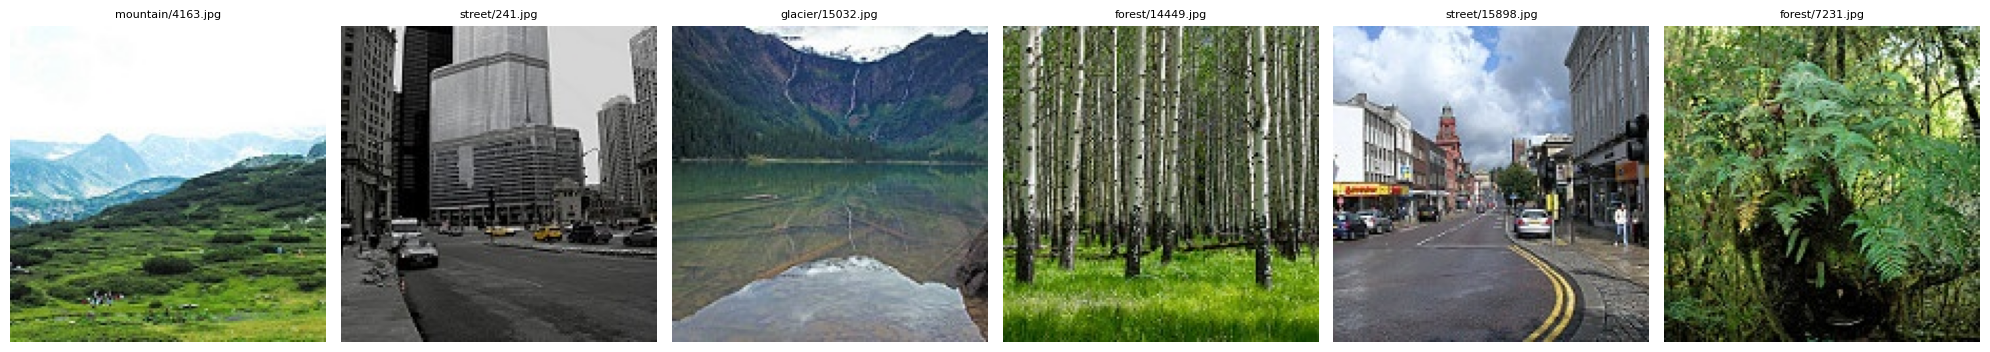


--- Sample Images from Test Dataset (/root/.cache/kagglehub/datasets/blourdhuraju/intel-image-classification-dataset/versions/1/Intel-Image-Classification/test) ---
Found 3000 images in /root/.cache/kagglehub/datasets/blourdhuraju/intel-image-classification-dataset/versions/1/Intel-Image-Classification/test. Displaying 6 samples:


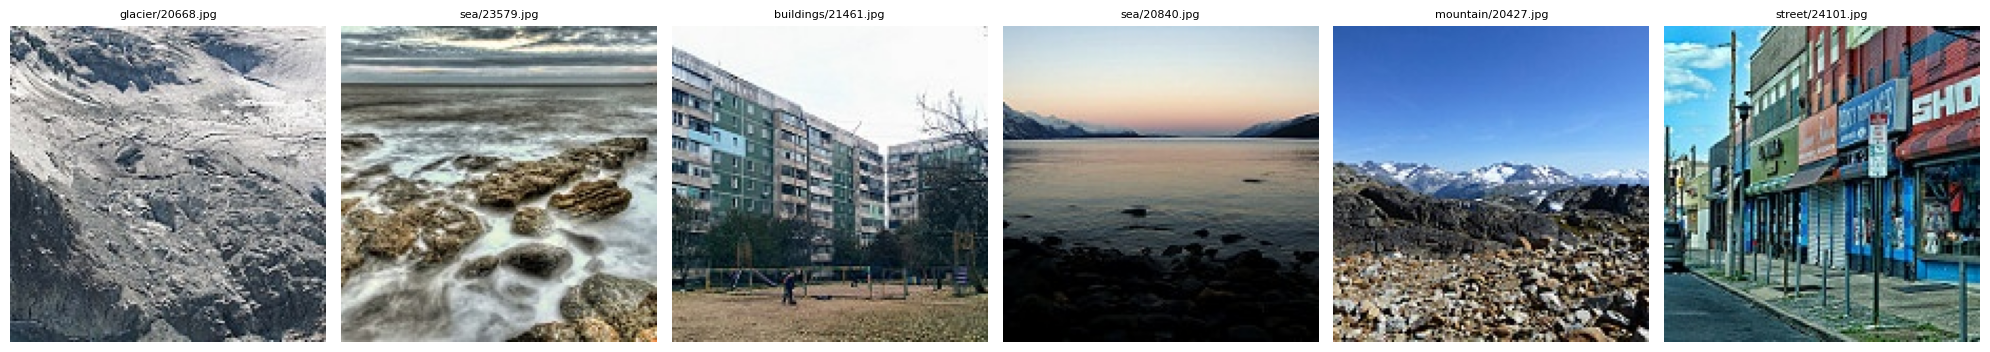

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig)
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(os.path.dirname(img_path)) + '/' + os.path.basename(img_path), fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Updated paths to include 'Intel-Image-Classification' subdirectory
train_path = os.path.join(path, 'Intel-Image-Classification', 'train')
print(f"\n--- Sample Images from Training Dataset ({train_path}) ---")
display_sample_images(train_path)

test_path = os.path.join(path, 'Intel-Image-Classification', 'test')
print(f"\n--- Sample Images from Test Dataset ({test_path}) ---")
display_sample_images(test_path)

In [ ]:
import tensorflow as tf

# Check if GPU is available
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
if tf.test.gpu_device_name():
    print('Default GPU Device: {}'.format(tf.test.gpu_device_name()))
else:
    print("Please install GPU version of TF or check Colab Runtime Settings.")

Num GPUs Available:  1
Default GPU Device: /device:GPU:0


In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configuration
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
EPOCHS = 10

# Data Generators
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Build DenseNet Model
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
base_model.trainable = False  # Freeze the base

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
print("Starting training...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

Found 10109 images belonging to 6 classes.
Found 2523 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Starting training...
Epoch 1/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 83s 174ms/step - accuracy: 0.8337 - loss: 0.4568 - val_accuracy: 0.8954 - val_loss: 0.2921
Epoch 2/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step - accuracy: 0.8882 - loss: 0.3043 - val_accuracy: 0.9033 - val_loss: 0.2651
Epoch 3/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.8986 - loss: 0.2727 - val_accuracy: 0.9005 - val_loss: 0.2683
Epoch 4/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9030 - loss: 0.2515 - val_accuracy: 0.9069 - val_loss: 0.2525
Epoch 5/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 19s 60ms/step - accuracy: 0.9129 - loss: 0.2284 - val_accuracy: 0.9116 - val_loss: 0.2631
Epoch 6/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.9154 - loss: 0.2197 - val_accuracy: 0.9065 - val_loss: 0.2636
Epoch 7/10
316/316 ━━━━━━━━━━━━━━━━━━━━ 20s 62ms/step - accuracy: 0.919

In [ ]:
# Evaluate the model
loss, accuracy = model.evaluate(test_generator)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 156ms/step - accuracy: 0.9107 - loss: 0.2528

Test Loss: 0.2528
Test Accuracy: 0.9107


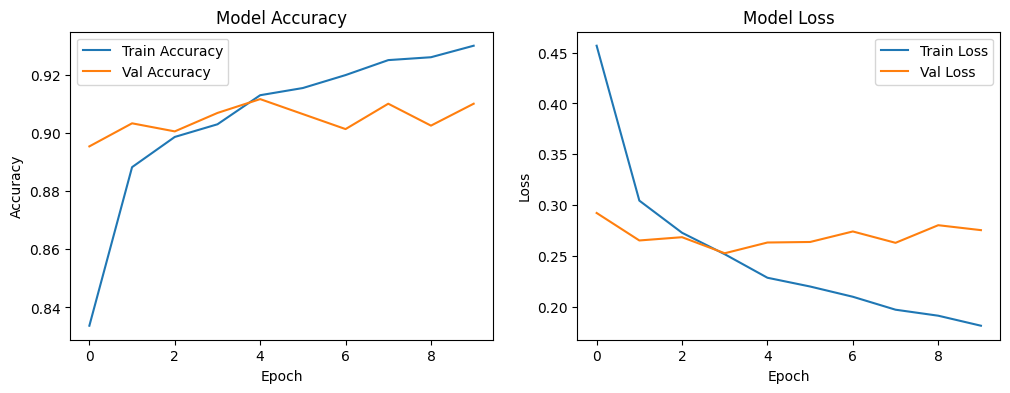

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation metrics
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()